# RQ1 – GEG vs Baseline: Fairness, Performance, and Trade-off

**Research Question 1**: Does GEG improve fairness compared to the baseline (no debiasing) without significantly degrading predictive performance?

- **Datasets**: cmc, crime, drug, law, obesity, park, wine  
- **GEG constraints**: `cp`, `dp`, `eo`  
- **Baseline**: logistic regression (no debiasing, `lr`)  
- **Fairness metrics**: Statistical Parity (SP), Equal Opportunity (EO), Average Odds (AO) – all as absolute values  
- **Performance metrics**: Accuracy, F1-score

## 1. Importazione delle Librerie

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", "{:.4f}".format)

EXPERIMENTS = Path(".")  # notebook lives inside experiments/
IMGS = EXPERIMENTS / "imgs"
IMGS.mkdir(exist_ok=True)

DATASETS   = ["cmc", "crime", "drug", "law", "obesity", "park", "wine"]
CONSTRAINTS = ["cp", "dp", "eo"]
FAIRNESS_METRICS  = ["wc_statistical_parity", "wc_equal_opportunity", "wc_average_odds"]
PERFORMANCE_METRICS = ["accuracy", "precision", "recall", "f1_score"]
METHODS = ["Baseline", "GEG-DP", "GEG-EO", "GEG-CP", 
           #"GEG-DP-POS", "GEG-EO-POS", "GEG-CP-POS"
           ]
METRIC_LABELS = {
    "wc_statistical_parity": "Statistical Parity",
    "wc_equal_opportunity":  "Equal Opportunity",
    "wc_average_odds":       "Average Odds",
    "accuracy":           "Accuracy",
    "precision":          "Precision",
    "recall":             "Recall",
    "f1_score":           "F1-score",
}
METHOD_LABELS = {
    "Baseline": "Baseline",
    "GEG-DP":   "GEG-SP",
    "GEG-EO":   "GEG-EO",
    "GEG-CP":   "GEG-CP",
    # "GEG-DP-POS": "GEG-SP-POS",
    # "GEG-EO-POS": "GEG-EO-POS",
    # "GEG-CP-POS": "GEG-CP-POS",
}
print("Libraries loaded.")

Libraries loaded.


## 2. Caricamento e Preparazione dei Dati

In [40]:
def load_baseline(datasets=DATASETS):
    """Load baseline (no-debiasing) results for RQ1 datasets."""
    dfs = []
    for ds in datasets:
        f = EXPERIMENTS / "results_baseline" / f"{ds}_baseline_results.csv"
        df = pd.read_csv(f)
        df["dataset"] = ds
        df["method"] = "Baseline"
        dfs.append(df)
    return pd.concat(dfs, ignore_index=True)


def load_geg_multi(datasets=DATASETS, constraints=CONSTRAINTS):
    """Load GEG multi-constraint results for RQ1 datasets."""
    dfs = []
    for ds in datasets:
        for c in constraints:
            f = EXPERIMENTS / "results_geg_multi" / f"{ds}_geg_{c}_results.csv"
            df = pd.read_csv(f)
            df["dataset"] = ds
            df["method"] = f"GEG-{c.upper()}"
            dfs.append(df)
    return pd.concat(dfs, ignore_index=True)
  
def load_geg_multi_pos(datasets=DATASETS, constraints=CONSTRAINTS):
  """Load GEG multi-constraint results for RQ1 datasets."""
  dfs = []
  for ds in datasets:
      for c in constraints:
          f = EXPERIMENTS / "results_geg_new" / f"{ds}_geg_{c}_results.csv"
          df = pd.read_csv(f)
          df["dataset"] = ds
          df["method"] = f"GEG-{c.upper()}-POS"
          dfs.append(df)
  return pd.concat(dfs, ignore_index=True)


baseline = load_baseline()
geg      = load_geg_multi()
# geg_pos = load_geg_multi_pos()
df_all   = pd.concat([baseline, geg], ignore_index=True)

# Absolute values for fairness metrics
for m in FAIRNESS_METRICS:
    df_all[m] = df_all[m].abs()

df_all["method"] = df_all["method"].map(METHOD_LABELS)

print(f"Loaded {len(df_all)} rows | methods: {df_all['method'].unique()}")
df_all.head()

Loaded 280 rows | methods: ['Baseline' 'GEG-CP' 'GEG-SP' 'GEG-EO']


,fold,accuracy,precision,recall,f1_score,statistical_parity,equal_opportunity,average_odds,wc_statistical_parity,wc_equal_opportunity,wc_average_odds,constraint,dataset,method
0,1,0.6014,0.5947,0.5545,0.5479,0.1374,0.3929,0.2019,0.1374,0.3929,0.2019,lr,cmc,Baseline
1,2,0.6014,0.5857,0.5520,0.5302,0.0550,0.0462,0.0358,0.0550,0.1508,0.0402,lr,cmc,Baseline
2,3,0.5878,0.5524,0.5476,0.5470,0.1159,0.3106,0.1356,0.1159,0.3106,0.1356,lr,cmc,Baseline
3,4,0.5918,0.6263,0.5636,0.5515,-0.0142,-0.0358,-0.0397,0.0142,0.0358,0.0480,lr,cmc,Baseline
4,5,0.6122,0.5675,0.5264,0.5247,0.1188,0.1039,0.0846,0.1188,0.2206,0.1028,lr,cmc,Baseline


## 3. Analisi delle Metriche di Fairness

Le metriche di fairness sono calcolate come differenze assolute tra gruppi:

$$\Delta_{SP} = |P(\hat{Y}=1 \mid A=0) - P(\hat{Y}=1 \mid A=1)|$$

$$\Delta_{EO} = |TPR_{A=0} - TPR_{A=1}|$$

$$\Delta_{AO} = \frac{1}{2}(|FPR_{A=0} - FPR_{A=1}| + |TPR_{A=0} - TPR_{A=1}|)$$

Valori più bassi indicano maggiore fairness.

In [41]:
METHODS_ORDER = ["Baseline", "GEG-CP", "GEG-SP", "GEG-EO"] #"GEG-CP-POS", "GEG-SP-POS", "GEG-EO-POS"]
PALETTE = {
    "Baseline": "#4C72B0",
    "GEG-CP":   "#DD8452",
    "GEG-SP":   "#55A868",
    "GEG-EO":   "#C44E52",
    "GEG-CP-POS": "#8172B2",
    "GEG-SP-POS": "#937860",
    "GEG-EO-POS": "#DA8BC3",
}

# Mean ± std across folds per dataset × method
fairness_summary = (
    df_all.groupby(["dataset", "method"])[FAIRNESS_METRICS]
    .agg(["mean", "std"])
    .reset_index()
)
fairness_summary.columns = ["_".join(c).strip("_") for c in fairness_summary.columns]
fairness_summary["method"] = pd.Categorical(fairness_summary["method"], categories=METHODS_ORDER, ordered=True)
fairness_summary = fairness_summary.sort_values(["dataset", "method"])
fairness_summary.head(12)

,dataset,method,wc_statistical_parity_mean,wc_statistical_parity_std,wc_equal_opportunity_mean,wc_equal_opportunity_std,wc_average_odds_mean,wc_average_odds_std
0,cmc,Baseline,0.1175,0.0607,0.2168,0.0981,0.1292,0.0586
1,cmc,GEG-CP,0.0529,0.0396,0.1258,0.0632,0.0777,0.0623
3,cmc,GEG-SP,0.0746,0.0722,0.1902,0.0620,0.1247,0.0581
2,cmc,GEG-EO,0.0479,0.0320,0.1543,0.0698,0.0822,0.0397
4,crime,Baseline,0.3821,0.0616,0.5188,0.2118,0.3437,0.1052
5,crime,GEG-CP,0.2328,0.1185,0.3184,0.1574,0.1901,0.0953
7,crime,GEG-SP,0.1935,0.1324,0.4223,0.1962,0.2425,0.1062
6,crime,GEG-EO,0.2965,0.0627,0.3931,0.1751,0.2439,0.0961
8,drug,Baseline,0.2135,0.1249,0.3590,0.1358,0.2169,0.0898
9,drug,GEG-CP,0.1281,0.0974,0.2795,0.0830,0.1572,0.0495


## 4. Analisi delle Metriche di Performance

In [42]:
perf_summary = (
    df_all.groupby(["dataset", "method"])[PERFORMANCE_METRICS]
    .agg(["mean", "std"])
    .reset_index()
)
perf_summary.columns = ["_".join(c).strip("_") for c in perf_summary.columns]
perf_summary["method"] = pd.Categorical(perf_summary["method"], categories=METHODS_ORDER, ordered=True)
perf_summary = perf_summary.sort_values(["dataset", "method"])
perf_summary.head(12)

,dataset,method,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_score_mean,f1_score_std
0,cmc,Baseline,0.6056,0.0327,0.5834,0.0372,0.5595,0.0322,0.5531,0.0332
1,cmc,GEG-CP,0.6103,0.0302,0.5908,0.0373,0.5653,0.0233,0.5581,0.0287
3,cmc,GEG-SP,0.6090,0.0331,0.5839,0.0445,0.5613,0.0329,0.5536,0.0371
2,cmc,GEG-EO,0.6049,0.0305,0.5839,0.0397,0.5611,0.0249,0.5553,0.0274
4,crime,Baseline,0.4744,0.0367,0.4339,0.0455,0.4522,0.0320,0.4271,0.0367
5,crime,GEG-CP,0.4257,0.0437,0.4061,0.0385,0.4017,0.0481,0.3838,0.0503
7,crime,GEG-SP,0.3425,0.0704,0.3325,0.0926,0.3191,0.0584,0.2806,0.0783
6,crime,GEG-EO,0.4468,0.0256,0.4087,0.0433,0.4215,0.0246,0.3923,0.0273
8,drug,Baseline,0.6870,0.0232,0.6185,0.0327,0.6139,0.0181,0.6107,0.0255
9,drug,GEG-CP,0.6822,0.0246,0.6119,0.0267,0.6067,0.0160,0.6020,0.0194


## 5. Tabella Comparativa Fairness vs Performance

La tabella mostra, per ogni dataset e metodo, le metriche di fairness (|SP|, |EO|, |AO|) e di performance (Acc, F1) come media ± deviazione standard sui fold di cross-validation.

In [43]:

from scipy.stats import wilcoxon

def vargha_delaney_a(x, y):
    """Vargha-Delaney A = P(X > Y) + 0.5*P(X == Y).
    A >= 0.71 or A <= 0.29  →  large effect (|A - 0.5| >= 0.21).
    """
    n = len(x) * len(y)
    more = sum(xi > yj for xi in x for yj in y)
    tie  = sum(xi == yj for xi in x for yj in y)
    return (more + 0.5 * tie) / n

# Explicit full list — independent of any later redefinition of PERFORMANCE_METRICS
_ALL_METRICS = [
    "wc_statistical_parity", "wc_equal_opportunity", "wc_average_odds",
    "accuracy", "precision", "recall", "f1_score",
]

stat_records = []
baseline_df = df_all[df_all["method"] == "Baseline"]

for ds in DATASETS:
    b_rows = baseline_df[baseline_df["dataset"] == ds].sort_values("fold")
    for geg_method in [m for m in METHODS_ORDER if m != "Baseline"]:
        g_rows = df_all[(df_all["dataset"] == ds) & (df_all["method"] == geg_method)].sort_values("fold")
        if len(g_rows) == 0:
            continue
        for metric in _ALL_METRICS:
            b_vals = b_rows[metric].values
            g_vals = g_rows[metric].values
            if len(b_vals) < 2 or len(b_vals) != len(g_vals):
                continue
            diff = g_vals - b_vals
            if np.all(diff == 0):
                p_val = 1.0
            else:
                try:
                    if metric in FAIRNESS_METRICS:
                        # For fairness metrics, we expect GEG to be better (lower) than Baseline
                        _, p_val = wilcoxon(b_vals, g_vals, alternative="greater")
                    else:
                        # For performance metrics, we expect GEG to be better (higher) than Baseline
                        _, p_val = wilcoxon(b_vals, g_vals, alternative="less")
                except Exception:
                    p_val = 1.0
            a = vargha_delaney_a(g_vals, b_vals)
            stat_records.append({
                "dataset":      ds,
                "method":       geg_method,
                "metric":       metric,
                "p_value":      p_val,
                "vda":          a,
                "significant":  p_val < 0.05,
                "large_effect": abs(a - 0.5) >= 0.21,
            })

stat_df = pd.DataFrame(stat_records)
print(f"Computed {len(stat_df)} statistical comparisons (Wilcoxon + Vargha-Delaney A)")
stat_df.head(14)


Computed 147 statistical comparisons (Wilcoxon + Vargha-Delaney A)


,dataset,method,metric,p_value,vda,significant,large_effect
0,cmc,GEG-CP,wc_statistical_parity,0.0020,0.1950,True,True
1,cmc,GEG-CP,wc_equal_opportunity,0.0039,0.1850,True,True
2,cmc,GEG-CP,wc_average_odds,0.0371,0.2550,True,True
3,cmc,GEG-CP,accuracy,0.2051,0.5550,False,False
4,cmc,GEG-CP,precision,0.2158,0.5900,False,False
5,cmc,GEG-CP,recall,0.2461,0.6500,False,False
6,cmc,GEG-CP,f1_score,0.3477,0.6200,False,False
7,cmc,GEG-SP,wc_statistical_parity,0.0098,0.3050,True,False
8,cmc,GEG-SP,wc_equal_opportunity,0.1250,0.3900,False,False
9,cmc,GEG-SP,wc_average_odds,0.5449,0.4650,False,False


In [44]:

def fmt(mean_col, std_col, df):
    return df[mean_col].map("{:.3f}".format) + " $\pm$ " + df[std_col].map("{:.3f}".format)

def fmt_stat(mean_col, std_col, metric_name, df, stat_df):
    """Format cells: \\textbf{} if significant + large effect, \\textit{} if significant only.
    Baseline rows are left unformatted (no comparison available).
    """
    base_str = fmt(mean_col, std_col, df)
    result = []
    for idx, row in df.iterrows():
        s = base_str.loc[idx]
        if row["method"] == "Baseline":
            result.append(s)
            continue
        match = stat_df[
            (stat_df["dataset"] == row["dataset"]) &
            (stat_df["method"]  == row["method"]) &
            (stat_df["metric"]  == metric_name)
        ]
        if match.empty:
            result.append(s)
            continue
        sig   = bool(match.iloc[0]["significant"])
        large = bool(match.iloc[0]["large_effect"])
        if sig and large:
            result.append(r"\textbf{" + s + "}")
        elif sig:
            result.append(r"\textit{" + s + "}")
        else:
            result.append(s)
    return pd.Series(result, index=df.index)

# Build combined summary table
combined = fairness_summary.merge(perf_summary, on=["dataset", "method"])
table = pd.DataFrame({
    "Dataset":   combined["dataset"],
    "Method":    combined["method"],
    "SP":        fmt_stat("wc_statistical_parity_mean", "wc_statistical_parity_std", "wc_statistical_parity", combined, stat_df),
    "EO":        fmt_stat("wc_equal_opportunity_mean",  "wc_equal_opportunity_std",  "wc_equal_opportunity",  combined, stat_df),
    "AO":        fmt_stat("wc_average_odds_mean",       "wc_average_odds_std",       "wc_average_odds",       combined, stat_df),
    "Accuracy":  fmt_stat("accuracy_mean",  "accuracy_std",  "accuracy",  combined, stat_df),
    "Precision": fmt_stat("precision_mean", "precision_std", "precision", combined, stat_df),
    "Recall":    fmt_stat("recall_mean",    "recall_std",    "recall",    combined, stat_df),
    "F1-score":  fmt_stat("f1_score_mean",  "f1_score_std",  "f1_score",  combined, stat_df),
})

print("=== RQ1 Summary Table: Fairness & Performance (mean ± std across 10 folds) ===")
print("    Bold   = significant (p<0.05) + large effect (|A−0.5|≥0.21)")
print("    Italic = significant (p<0.05) only\n")
display(table.set_index(["Dataset", "Method"]))


=== RQ1 Summary Table: Fairness & Performance (mean ± std across 10 folds) ===
    Bold   = significant (p<0.05) + large effect (|A−0.5|≥0.21)
    Italic = significant (p<0.05) only



SP                          EO  \
Dataset Method                                                             
cmc     Baseline           0.117 $\pm$ 0.061           0.217 $\pm$ 0.098   
        GEG-CP    \textbf{0.053 $\pm$ 0.040}  \textbf{0.126 $\pm$ 0.063}   
        GEG-SP    \textit{0.075 $\pm$ 0.072}           0.190 $\pm$ 0.062   
        GEG-EO    \textbf{0.048 $\pm$ 0.032}  \textbf{0.154 $\pm$ 0.070}   
crime   Baseline           0.382 $\pm$ 0.062           0.519 $\pm$ 0.212   
        GEG-CP    \textbf{0.233 $\pm$ 0.118}  \textbf{0.318 $\pm$ 0.157}   
        GEG-SP    \textbf{0.193 $\pm$ 0.132}           0.422 $\pm$ 0.196   
        GEG-EO    \textbf{0.296 $\pm$ 0.063}  \textit{0.393 $\pm$ 0.175}   
drug    Baseline           0.213 $\pm$ 0.125           0.359 $\pm$ 0.136   
        GEG-CP    \textit{0.128 $\pm$ 0.097}  \textbf{0.280 $\pm$ 0.083}   
        GEG-SP    \textbf{0.082 $\pm$ 0.073}           0.300 $\pm$ 0.140   
        GEG-EO             0.194 $\pm$ 0.139           0.324 $\pm$ 0.132   
law     Baseline           0.083 $\pm$ 0.019           0.105 $\pm$ 0.029   
        GEG-CP    \textbf{0.046 $\pm$ 0.031}           0.103 $\pm$ 0.031   
        GEG-SP    \textbf{0.018 $\pm$ 0.016}           0.097 $\pm$ 0.039   
        GEG-EO    \textbf{0.047 $\pm$ 0.025}           0.078 $\pm$ 0.040   
obesity Baseline           0.050 $\pm$ 0.042           0.573 $\pm$ 0.205   
        GEG-CP             0.061 $\pm$ 0.046  \textbf{0.316 $\pm$ 0.138}   
        GEG-SP             0.050 $\pm$ 0.042           0.447 $\pm$ 0.095   
        GEG-EO             0.063 $\pm$ 0.048  \textbf{0.368 $\pm$ 0.118}   
park    Baseline           0.214 $\pm$ 0.072           0.352 $\pm$ 0.100   
        GEG-CP    \textbf{0.083 $\pm$ 0.064}  \textbf{0.139 $\pm$ 0.084}   
        GEG-SP    \textbf{0.053 $\pm$ 0.027}  \textbf{0.137 $\pm$ 0.060}   
        GEG-EO    \textbf{0.131 $\pm$ 0.051}  \textbf{0.156 $\pm$ 0.062}   
wine    Baseline           0.115 $\pm$ 0.046           0.155 $\pm$ 0.049   
        GEG-CP    \textbf{0.053 $\pm$ 0.038}  \textbf{0.083 $\pm$ 0.049}   
        GEG-SP    \textbf{0.057 $\pm$ 0.023}  \textbf{0.087 $\pm$ 0.029}   
        GEG-EO    \textbf{0.024 $\pm$ 0.022}  \textbf{0.058 $\pm$ 0.024}   

                                          AO                    Accuracy  \
Dataset Method                                                             
cmc     Baseline           0.129 $\pm$ 0.059           0.606 $\pm$ 0.033   
        GEG-CP    \textbf{0.078 $\pm$ 0.062}           0.610 $\pm$ 0.030   
        GEG-SP             0.125 $\pm$ 0.058           0.609 $\pm$ 0.033   
        GEG-EO             0.082 $\pm$ 0.040           0.605 $\pm$ 0.031   
crime   Baseline           0.344 $\pm$ 0.105           0.474 $\pm$ 0.037   
        GEG-CP    \textbf{0.190 $\pm$ 0.095}           0.426 $\pm$ 0.044   
        GEG-SP    \textbf{0.242 $\pm$ 0.106}           0.343 $\pm$ 0.070   
        GEG-EO    \textbf{0.244 $\pm$ 0.096}           0.447 $\pm$ 0.026   
drug    Baseline           0.217 $\pm$ 0.090           0.687 $\pm$ 0.023   
        GEG-CP    \textbf{0.157 $\pm$ 0.049}           0.682 $\pm$ 0.025   
        GEG-SP    \textbf{0.143 $\pm$ 0.065}           0.682 $\pm$ 0.030   
        GEG-EO    \textit{0.191 $\pm$ 0.087}           0.692 $\pm$ 0.023   
law     Baseline           0.073 $\pm$ 0.018           0.666 $\pm$ 0.015   
        GEG-CP             0.059 $\pm$ 0.029  \textbf{0.683 $\pm$ 0.010}   
        GEG-SP             0.063 $\pm$ 0.019           0.673 $\pm$ 0.015   
        GEG-EO             0.051 $\pm$ 0.026  \textbf{0.688 $\pm$ 0.012}   
obesity Baseline           0.316 $\pm$ 0.093           0.668 $\pm$ 0.044   
        GEG-CP    \textbf{0.195 $\pm$ 0.060}           0.623 $\pm$ 0.105   
        GEG-SP    \textbf{0.217 $\pm$ 0.052}  \textit{0.687 $\pm$ 0.035}   
        GEG-EO    \textbf{0.209 $\pm$ 0.051}           0.648 $\pm$ 0.025   
park    Baseline           0.239 $\pm$ 0.078           0.473 $\pm$ 0.020   
        GEG-C

In [45]:
# LaTeX export for paper
latex_table = table.set_index(["Dataset", "Method"]).to_latex("rq1_summary.tex",
    caption="RQ1 -- Fairness and performance comparison: GEG vs Baseline (mean $\\pm$ std across 10 folds).",
    label="tab:rq1_results",
    escape=False,
)
print(latex_table)

None


## 6. Visualizzazione della Fairness per Metodo

Grafici a barre raggruppati per dataset: per ogni metrica di fairness si confrontano Baseline e le tre varianti GEG.

In [46]:
plot_data = df_all.melt(id_vars=["dataset", "method"], value_vars=FAIRNESS_METRICS, var_name="metric", value_name="value")
metric_map = {m: METRIC_LABELS[m] for m in FAIRNESS_METRICS}
plot_data["metric"] = plot_data["metric"].map(metric_map)
plot_data

,dataset,method,metric,value
0,cmc,Baseline,Statistical Parity,0.1374
1,cmc,Baseline,Statistical Parity,0.0550
2,cmc,Baseline,Statistical Parity,0.1159
3,cmc,Baseline,Statistical Parity,0.0142
4,cmc,Baseline,Statistical Parity,0.1188
...,...,...,...,...
835,wine,GEG-EO,Average Odds,0.0543
836,wine,GEG-EO,Average Odds,0.0541
837,wine,GEG-EO,Average Odds,0.0420
838,wine,GEG-EO,Average Odds,0.0428


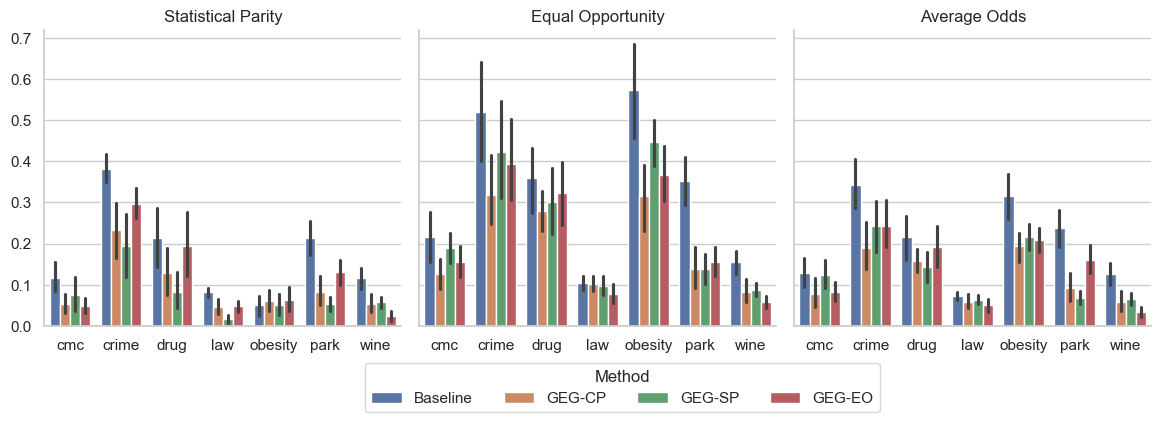

In [55]:
g = sns.catplot(
    data=plot_data,
    x="dataset",
    y="value",
    hue="method",
    col="metric",
    kind="bar",
    palette=PALETTE,
    height=4,
    aspect=1,
    # col_wrap=1
)

g.set_titles("{col_name}")
g.set_axis_labels("", "")
g.legend.set_title("Method")
sns.move_legend(g, "lower center", ncol=4, title="Method", bbox_to_anchor=(0.5, -0.07), frameon=True)
# plt.tight_layout()
plt.savefig(IMGS / "rq1_fairness_comparison.pdf", bbox_inches="tight")


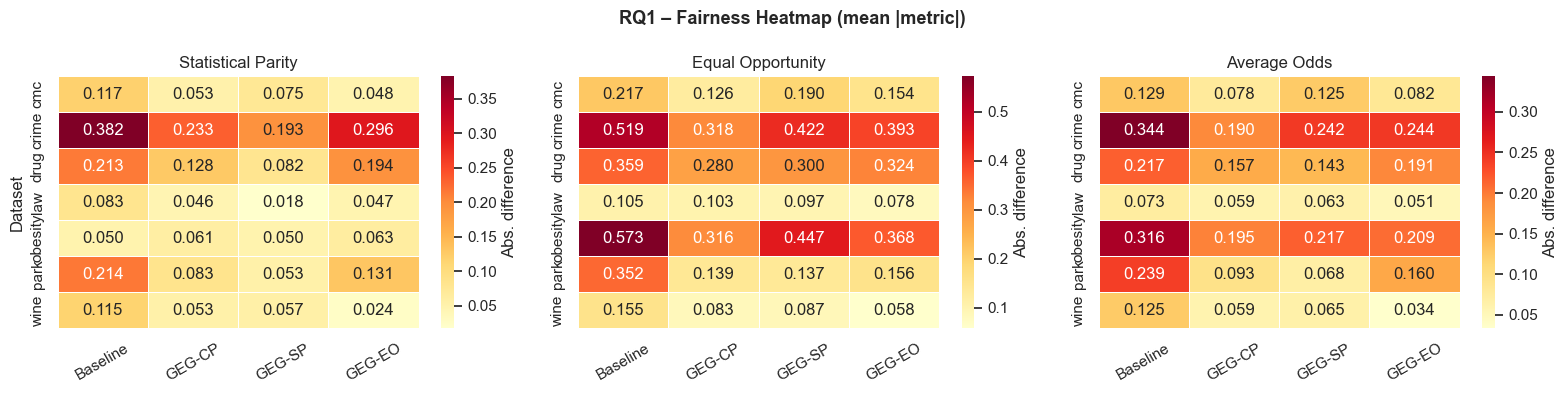

In [48]:
# Heatmap: average fairness reduction vs baseline
pivot_sp = fairness_summary.pivot(index="dataset", columns="method", values="wc_statistical_parity_mean")
pivot_eo = fairness_summary.pivot(index="dataset", columns="method", values="wc_equal_opportunity_mean")
pivot_ao = fairness_summary.pivot(index="dataset", columns="method", values="wc_average_odds_mean")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, pivot, title in zip(axes,
                             [pivot_sp, pivot_eo, pivot_ao],
                             ["Statistical Parity", "Equal Opportunity", "Average Odds"]):
    pivot = pivot[METHODS_ORDER]
    sns.heatmap(pivot, ax=ax, annot=True, fmt=".3f", cmap="YlOrRd",
                linewidths=0.5, cbar_kws={"label": "Abs. difference"})
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel("Dataset" if ax == axes[0] else "")
    ax.tick_params(axis="x", rotation=30)

fig.suptitle("RQ1 – Fairness Heatmap (mean |metric|)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(IMGS / "rq1_fairness_heatmap.pdf", bbox_inches="tight")
plt.show()

## 7. Visualizzazione della Performance per Metodo

In [49]:
plot_data_perf = df_all.melt(id_vars=["dataset", "method"], value_vars=PERFORMANCE_METRICS, var_name="metric", value_name="value")
metric_map_perf = {m: METRIC_LABELS[m] for m in PERFORMANCE_METRICS}
plot_data_perf["metric"] = plot_data_perf["metric"].map(metric_map_perf)
plot_data_perf.head()

,dataset,method,metric,value
0,cmc,Baseline,Accuracy,0.6014
1,cmc,Baseline,Accuracy,0.6014
2,cmc,Baseline,Accuracy,0.5878
3,cmc,Baseline,Accuracy,0.5918
4,cmc,Baseline,Accuracy,0.6122


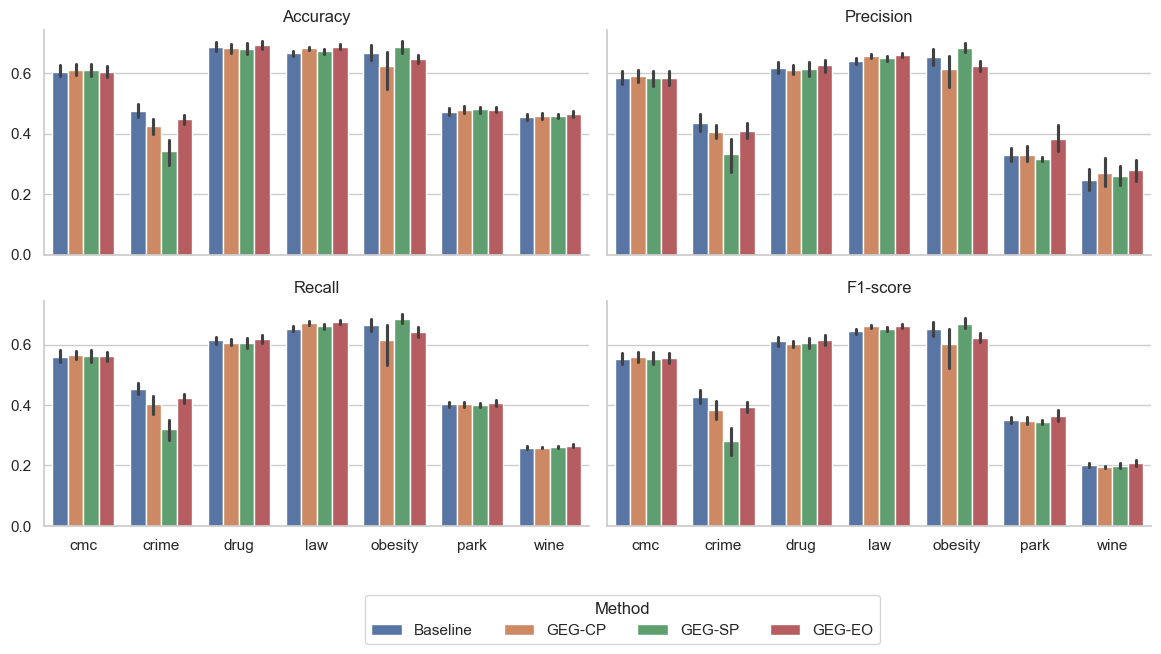

In [50]:
g = sns.catplot(
    data=plot_data_perf,
    x="dataset",
    y="value",
    hue="method",
    col="metric",
    kind="bar",
    palette=PALETTE,
    height=3,
    aspect=2,
    col_wrap=2
)
g.set_axis_labels("", "")
g.set_titles("{col_name}")
g.legend.set_title("Method")
# Move legend to bottom
sns.move_legend(g, "lower center", ncol=4, title="Method", bbox_to_anchor=(0.5, -0.1), frameon=True)
# plt.tight_layout()
plt.savefig(IMGS / "rq1_performance_comparison.pdf", bbox_inches="tight")

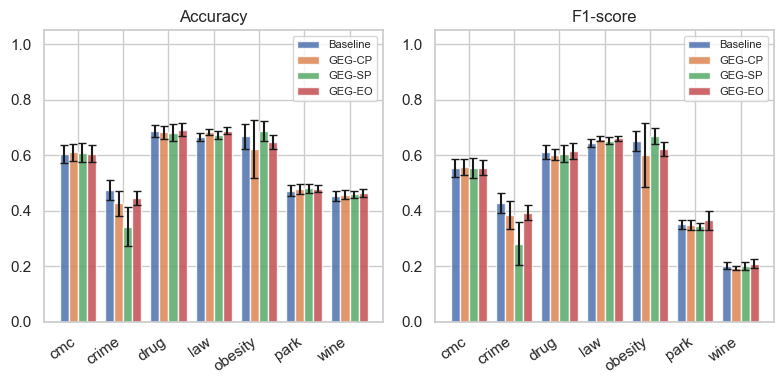

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4), sharey=False)

PERFORMANCE_METRICS = ["accuracy", "f1_score"]

for ax, metric in zip(axes, PERFORMANCE_METRICS):
    mean_col = f"{metric}_mean"
    std_col  = f"{metric}_std"

    x = np.arange(len(DATASETS))
    width = 0.2
    offsets = np.linspace(-1.5 * width, 1.5 * width, len(METHODS_ORDER))

    for i, method in enumerate(METHODS_ORDER):
        sub = perf_summary[perf_summary["method"] == method].set_index("dataset").reindex(DATASETS)
        ax.bar(
            x + offsets[i],
            sub[mean_col],
            width,
            yerr=sub[std_col],
            label=method,
            color=PALETTE[method],
            capsize=3,
            alpha=0.85,
        )

    ax.set_xticks(x)
    ax.set_xticklabels(DATASETS, rotation=35, ha="right")
    ax.set_ylabel("")
    ax.set_title(METRIC_LABELS[metric])
    ax.legend(fontsize=8)
    ax.set_ylim(0, 1.05)

# fig.suptitle("RQ1 – Performance Metrics: GEG vs Baseline", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(IMGS / "rq1_performance_bar.pdf", bbox_inches="tight")
plt.show()

## 8. Analisi del Trade-off Fairness–Performance

Viene calcolato un indice composito:

$$T(\alpha) = \alpha \cdot \text{Perf} + (1 - \alpha) \cdot (1 - \text{Fair})$$

dove $\text{Perf}$ è l'F1-score medio e $\text{Fair} = \frac{|SP| + |EO| + |AO|}{3}$ è la fairness media (valori bassi = più fair).  
$\alpha \in [0, 1]$ bilancia l'importanza relativa di performance e fairness.

In [52]:
df_all

,fold,accuracy,precision,recall,f1_score,statistical_parity,equal_opportunity,average_odds,wc_statistical_parity,wc_equal_opportunity,wc_average_odds,constraint,dataset,method
0,1,0.6014,0.5947,0.5545,0.5479,0.1374,0.3929,0.2019,0.1374,0.3929,0.2019,lr,cmc,Baseline
1,2,0.6014,0.5857,0.5520,0.5302,0.0550,0.0462,0.0358,0.0550,0.1508,0.0402,lr,cmc,Baseline
2,3,0.5878,0.5524,0.5476,0.5470,0.1159,0.3106,0.1356,0.1159,0.3106,0.1356,lr,cmc,Baseline
3,4,0.5918,0.6263,0.5636,0.5515,-0.0142,-0.0358,-0.0397,0.0142,0.0358,0.0480,lr,cmc,Baseline
4,5,0.6122,0.5675,0.5264,0.5247,0.1188,0.1039,0.0846,0.1188,0.2206,0.1028,lr,cmc,Baseline
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
275,6,0.4544,0.2295,0.2740,0.2293,0.0425,0.0703,0.0530,0.0425,0.0703,0.0543,eo,wine,GEG-EO
276,7,0.4920,0.2549,0.2642,0.2047,0.0562,0.0429,0.0541,0.0562,0.0609,0.0541,eo,wine,GEG-EO
277,8,0.4663,0.2346,0.2593,0.1896,0.0345,0.0292,0.0362,0.0345,0.0657,0.0420,eo,wine,GEG-EO
278,9,0.4567,0.2231,0.2688,0.2261,0.0328,0.0788,0.0428,0.0328,0.0788,0.0428,eo,wine,GEG-EO


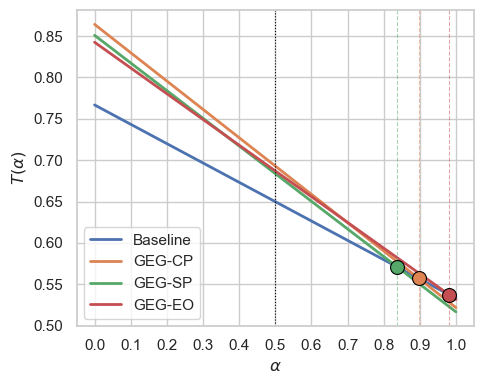


Global means:
   method  accuracy  f1_score  fair_mean  perf_mean
Baseline    0.5753    0.4910     0.2332     0.5331
  GEG-CP    0.5657    0.4782     0.1359     0.5220
  GEG-SP    0.5617    0.4719     0.1491     0.5168
  GEG-EO    0.5747    0.4886     0.1575     0.5317


In [53]:
# Compute per-method global means (averaged over all datasets and folds)
global_means = (
    df_all.groupby("method")[FAIRNESS_METRICS + PERFORMANCE_METRICS]
    .mean()
    .reset_index()
)
global_means["fair_mean"] = global_means[FAIRNESS_METRICS].mean(axis=1)
global_means["perf_mean"] = global_means[PERFORMANCE_METRICS].mean(axis=1)
global_means["method"] = pd.Categorical(global_means["method"], categories=METHODS_ORDER, ordered=True)
global_means = global_means.sort_values("method")

alphas = np.linspace(0, 1, 101)
fig, ax = plt.subplots(figsize=(5, 4))

# Plot lines and collect (alpha, score) per method
method_scores = {}
for _, row in global_means.iterrows():
    perf = row["perf_mean"]
    fair = row["fair_mean"]
    scores = alphas * perf + (1 - alphas) * (1 - fair)
    method_scores[row["method"]] = (perf, fair, scores)
    ax.plot(alphas, scores, label=row["method"], color=PALETTE[row["method"]], lw=2)

# Mark intersections: Baseline crosses each GEG variant
# T_base(α) = T_geg(α)  =>  α*(p_b - p_g + f_b - f_g) = f_b - f_g
# => α* = (f_b - f_g) / (p_b - p_g + f_b - f_g)
base_perf, base_fair, _ = method_scores["Baseline"]
for method in ["GEG-CP", "GEG-SP", "GEG-EO", #"GEG-CP-POS", "GEG-SP-POS", "GEG-EO-POS"
               ]:
    if method not in method_scores:
        continue
    m_perf, m_fair, _ = method_scores[method]
    denom = (base_perf - m_perf) + (base_fair - m_fair)
    if abs(denom) < 1e-12:
        continue  # parallel lines, no intersection
    alpha_star = (base_fair - m_fair) / denom
    if 0 <= alpha_star <= 1:
        score_star = alpha_star * base_perf + (1 - alpha_star) * (1 - base_fair)
        ax.scatter(alpha_star, score_star, color=PALETTE[method],
                   s=100, zorder=6, edgecolors="black", linewidths=0.8)
        ax.axvline(alpha_star, color=PALETTE[method], lw=0.8, linestyle="--", alpha=0.5)
        # ax.annotate(f"α={alpha_star:.2f}", (alpha_star, score_star),
        #             xytext=(5, -12), textcoords="offset points",
        #             fontsize=7, color=PALETTE[method])
ax.axvline(0.5, color="black", lw=0.8, linestyle=":", alpha=1)
ax.set_xticks(np.arange(0, 1.1, 0.1))
# ax.set_xticks(np.append(ax.get_xticks(), 0.5))
ax.set_xlabel("$\\alpha$")
ax.set_ylabel("$T(\\alpha)$")
# ax.set_title("RQ1 – Trade-off Index T(α) at Varying α", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig(IMGS / "rq1_tradeoff_alpha.pdf", bbox_inches="tight")
plt.show()

print("\nGlobal means:\n", global_means[["method", "accuracy", "f1_score", "fair_mean", "perf_mean"]].to_string(index=False))

## 9. Grafico di Pareto: Trade-off Fairness–Performance

Lo scatter plot mostra ogni (metodo, dataset) nello spazio fairness–performance.  
I punti sul **fronte di Pareto** (nessun altro punto è migliore su entrambi gli assi) sono evidenziati con una stella.

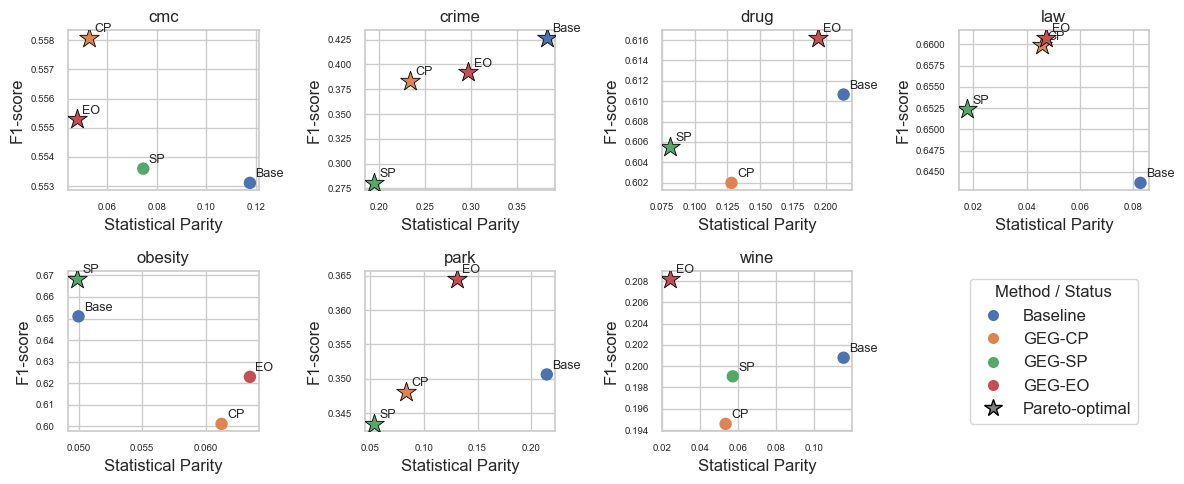

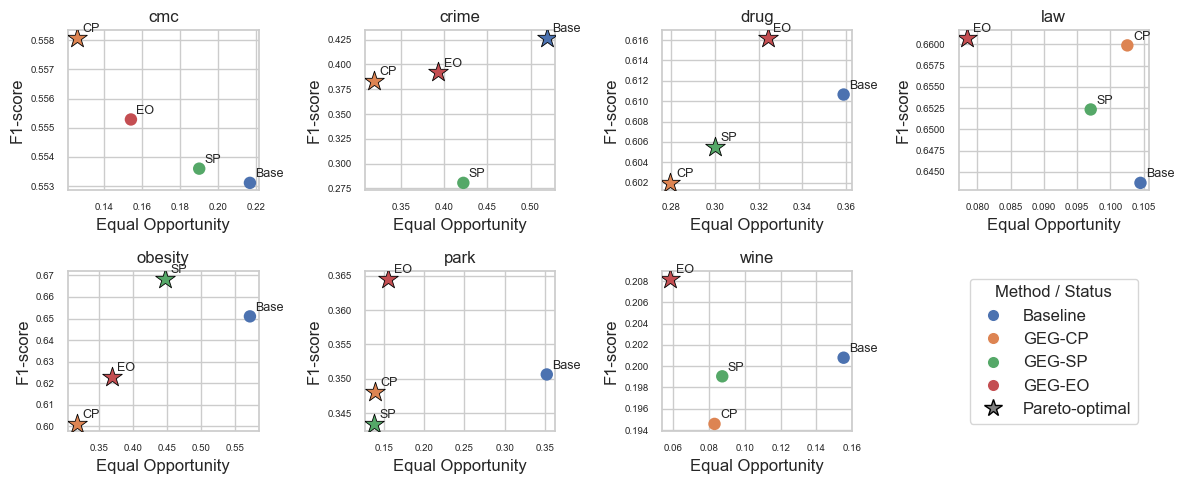

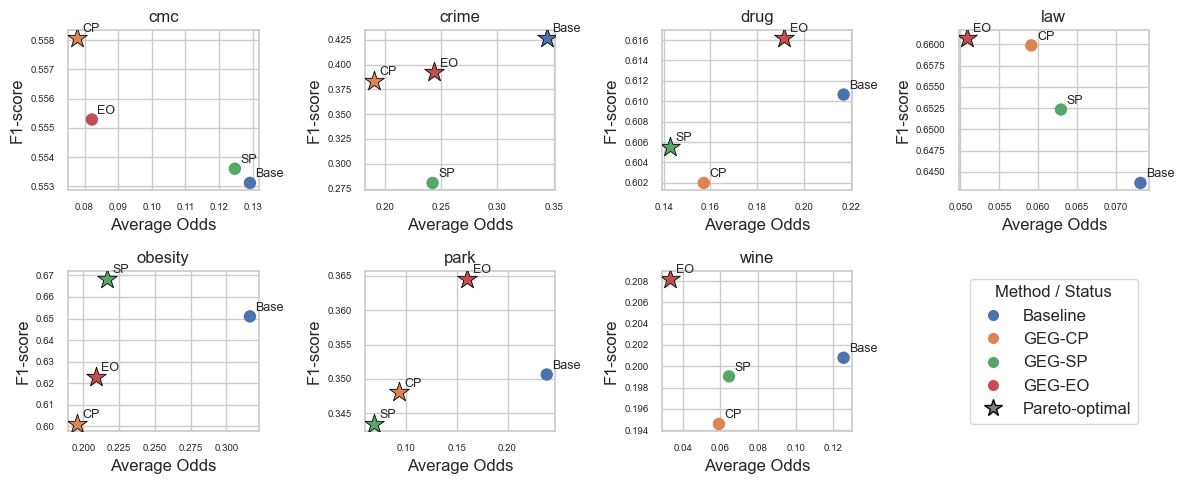

In [54]:
def is_pareto_efficient(costs):
    """Return boolean mask of Pareto-efficient points (minimise costs[:,0], maximise costs[:,1])."""
    n = len(costs)
    dominated = np.zeros(n, dtype=bool)
    for i in range(n):
        for j in range(n):
            if i == j:
                continue
            if costs[j, 0] <= costs[i, 0] and costs[j, 1] >= costs[i, 1]:
                if costs[j, 0] < costs[i, 0] or costs[j, 1] > costs[i, 1]:
                    dominated[i] = True
                    break
    return ~dominated


# Per-(dataset, method) scatter data
scatter_data = combined[["dataset", "method",
                          "wc_statistical_parity_mean", "wc_equal_opportunity_mean",
                          "wc_average_odds_mean", "f1_score_mean"]].copy()
scatter_data["fair_mean"] = scatter_data[["wc_statistical_parity_mean",
                                          "wc_equal_opportunity_mean",
                                          "wc_average_odds_mean"]].mean(axis=1)

for fairness_col, fair_label, fname in [
    ("wc_statistical_parity_mean", "Statistical Parity", "rq1_pareto_sp_per_dataset.pdf"),
    ("wc_equal_opportunity_mean",  "Equal Opportunity",  "rq1_pareto_eo_per_dataset.pdf"),
    ("wc_average_odds_mean",       "Average Odds",       "rq1_pareto_ao_per_dataset.pdf"),
]:
    fig, axes = plt.subplots(2, 4, figsize=(12, 5), sharex=False, sharey=False)
    axes_flat = axes.flatten()

    for ax_idx, ds in enumerate(DATASETS):
        ax = axes_flat[ax_idx]
        ds_data = scatter_data[scatter_data["dataset"] == ds].copy().reset_index(drop=True)
        ds_data = ds_data.set_index("method").reindex(METHODS_ORDER).reset_index()

        pts = ds_data[[fairness_col, "f1_score_mean"]].values
        pareto_mask = is_pareto_efficient(pts)

        for i, row in ds_data.iterrows():
            mx = row[fairness_col]
            my = row["f1_score_mean"]
            method = row["method"]
            is_pareto = pareto_mask[i]
            ax.scatter(mx, my,
                       color=PALETTE[method],
                       s=220 if is_pareto else 80,
                       marker="*" if is_pareto else "o",
                       edgecolors="black" if is_pareto else "none",
                       linewidths=0.6,
                       zorder=5 if is_pareto else 3,
                       label=method)
            ax.annotate(method.replace("GEG-", "").replace("Baseline", "Base"),
                        (mx, my), fontsize=9,
                        xytext=(4, 4), textcoords="offset points")

        ax.set_title(ds)
        ax.set_xlabel(f"{fair_label}", fontsize=12)
        ax.set_ylabel("F1-score", fontsize=12)
        ax.tick_params(labelsize=7)

    # Hide the unused 8th subplot (we have 7 datasets, 2×4 grid = 8 slots)
    axes_flat[-1].set_visible(False)

    # Shared legend in the empty 8th panel position
    legend_ax = axes_flat[-1]
    legend_ax.set_visible(True)
    legend_ax.axis("off")
    method_handles = [
        plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=PALETTE[m],
                   markersize=9, label=m)
        for m in METHODS_ORDER
    ]
    pareto_handle = plt.Line2D([0], [0], marker="*", color="w",
                               markerfacecolor="grey", markeredgecolor="black",
                               markersize=13, label="Pareto-optimal")
    legend_ax.legend(handles=method_handles + [pareto_handle],
                     loc="center", fontsize=12, frameon=True, title="Method / Status")

    # fig.suptitle(f"RQ1 – Pareto Front per Dataset  ({fair_label})", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig(IMGS / fname, bbox_inches="tight")
    plt.show()